In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

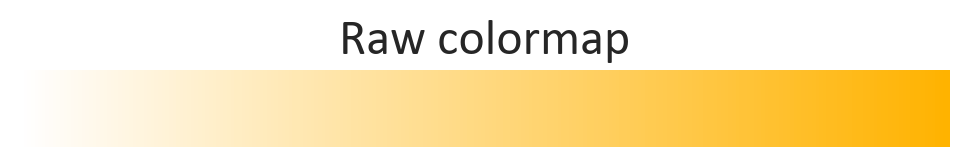

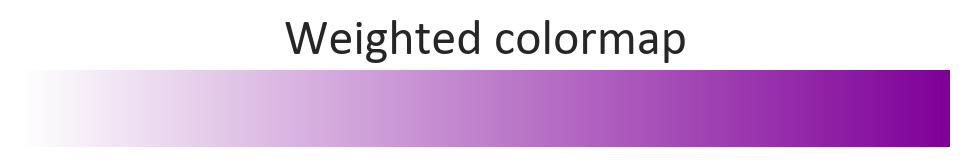

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

# Add font family to the rcParams (from tff file)
from matplotlib import font_manager

font_path = "/home/galkepler/.fonts/calibri-regular.ttf"
font_manager.fontManager.addfont(font_path)


mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "Calibri",
        # "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "font.sans-serif": ["Calibri", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, transparent=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=transparent, **savefig_kwargs)

mpl.rcParams["font.family"] = "Calibri"  # or any other font you want

# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/media/storage/phd/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/revision/fig_BAG")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
predictions_df = pd.read_csv("BAG_data.csv", index_col=0)
# predictions_df = predictions_df.filter(regex="BAG")

In [5]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [6]:
import numpy as np
import pandas as pd

def compute_joint_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    sex_col: str = "sex",
    male_label = 0,
    female_label = 1,
    start_col: str = "range_start",
    end_col: str = "range_end",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Computes joint post-stratification weights for Age and Sex so the sample
    matches an external census distribution.
    
    Parameters
    ----------
    sample_df : DataFrame with age and sex columns.
    pop_df    : DataFrame with [range_start, range_end, male, female].
    male_label/female_label : The values used in sample_df['sex'] (e.g., 0 and 1).
    cap       : Optional multiplier to truncate extreme weights.
    """
    # 1. Validation: Ensure all columns exist
    required_sample = [age_col, sex_col]
    required_pop = [start_col, end_col, "male", "female"]
    
    for col in required_sample:
        if col not in sample_df.columns:
            raise KeyError(f"Column '{col}' not found in sample_df. Available: {list(sample_df.columns)}")
    for col in required_pop:
        if col not in pop_df.columns:
            raise KeyError(f"Column '{col}' not found in pop_df. Available: {list(pop_df.columns)}")

    # 2. Tidy population table and convert to Long Format
    pop = pop_df.sort_values(start_col).copy()
    pop_long = pop.melt(
        id_vars=[start_col, end_col],
        value_vars=['male', 'female'],
        var_name='sex_str',
        value_name='pop_val'
    )
    
    # Map 'male'/'female' strings to the labels in your sample (0 and 1)
    pop_long[sex_col] = pop_long['sex_str'].map({'male': male_label, 'female': female_label})
    pop_long['prop_pop'] = pop_long['pop_val'] / pop_long['pop_val'].sum()
    
    # 3. Create Age Bins
    # edges define brackets: [0, 5, 10, ..., 90, 1000001]
    edges = sorted(list(pop[start_col].unique()) + [int(pop[end_col].max()) + 1])
    bin_labels = sorted(list(pop[start_col].unique()))
    
    sample = sample_df.copy()
    sample['age_bin_start'] = pd.cut(
        sample[age_col], 
        bins=edges, 
        labels=bin_labels, 
        right=False # standard for age: [start, end)
    )
    
    if sample['age_bin_start'].isna().any():
        print("Warning: Some participants fall outside the census age ranges.")

    # 4. Calculate Sample Proportions per (Age, Sex) cell
    sample_counts = sample.groupby(['age_bin_start', sex_col], observed=False).size().reset_index(name='n_sample')
    sample_counts['prop_sample'] = sample_counts['n_sample'] / sample_counts['n_sample'].sum()
    
    # Ensure types match for merging
    sample_counts['age_bin_start'] = sample_counts['age_bin_start'].astype(pop_long[start_col].dtype)
    
    # 5. Calculate Weight Factors (Population Proportion / Sample Proportion)
    weights_lookup = pd.merge(
        pop_long[[start_col, sex_col, 'prop_pop']],
        sample_counts,
        left_on=[start_col, sex_col],
        right_on=['age_bin_start', sex_col],
        how='left'
    )
    weights_lookup['weight_factor'] = weights_lookup['prop_pop'] / weights_lookup['prop_sample'].replace(0, np.nan)
    
    # 6. Map Weights back to individual sample rows
    sample['age_bin_start'] = sample['age_bin_start'].astype(pop_long[start_col].dtype)
    sample_with_weights = pd.merge(
        sample,
        weights_lookup[[start_col, sex_col, 'weight_factor']],
        left_on=['age_bin_start', sex_col],
        right_on=[start_col, sex_col],
        how='left'
    )
    
    w = sample_with_weights['weight_factor'].fillna(0).to_numpy()
    
    # 7. Apply optional cap and Rescale so mean weight = 1
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean() if any(w > 0) else 1.0
        w = np.clip(w, 0, cap * mean_pos)
        
    if any(w > 0):
        w = w / w.mean()
    else:
        print("Error: No matches found between sample and census. Weights are all zero.")

    if return_bin_table:
        return w, weights_lookup

    

    return w

In [7]:
df_cov = pd.read_csv("~/Projects/plasticityhub/sessions.csv")
df_cov["subject_code"] = (
    df_cov["subject_code"]
    .astype(str)
    .str.replace("-", "")
    .str.replace(" ", "")
    .str.replace("_", "")
)
# df_cov = pd.read_csv("~/Projects/neuroaging/data/external/sessions.csv")
df_cov = df_cov.drop_duplicates(subset=["subject_code"]).set_index("subject_code")
df_cov["sex"] = df_cov["sex"].map({"M": 0, "F": 1})
# df_cov = pd.read_pickle(f"/media/storage/phd/papers/aging/{ATLAS}/gm_vol.pkl").reset_index(
#     drop=True
# )
# df_cov = pd.read_csv("~/Projects/plasticityhub/sessions.csv")
# df_cov = pd.read_csv("qV1v.csv")

# finished_subjects = (
#     pd.read_csv("/media/storage/phd/papers/aging/schaefer2018tian2020_400_7/subjects.csv")
#     .values.flatten()
#     .tolist()
# )
# df_cov = df_cov[df_cov["Subject Code"].isin(finished_subjects)]

# df_cov = df_cov.groupby("subject_code").first()
df = df_cov.merge(predictions_df, left_on="subject_code", right_index=True, how="outer")
df = df.dropna(subset="stacked_BAG")
# merge with cov
# df_cov = df_cov.merge(cov, left_on="subject_code", right_index=True, how="inner")
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)


# exercise_frequency_mapping = {
#     "פעמיים-שלוש בשבוע": 2.5,
#     "1-1": 1.5,
#     "יותר מ-3 פעמים בשבוע": 4,
# }
# df_cov["exercise_frequency"] = df_cov["exercise_frequency"].map(
#     exercise_frequency_mapping
# )
df.loc[df["filled"].fillna(False), "number_of_children"] = df.loc[
    df["filled"].fillna(False), "number_of_children"
].fillna(0)

education_level_mapping = {
    "elementary school": 1,
    "partial high school": 2,
    "high_school": 3,
    "post-secondary": 4,
    "undergraduate": 5,
    "bachelor's degree": 6,
    "U": np.nan,
    # "other": np.nan,
}
df["education_level"] = df["education_level"].map(education_level_mapping)

for col in ["blood_sugar", "blood_pressure", "thyroids", "lipids"]:
    df[col] = (
        df[col]
        .str.lower()
        .map(
            {
                "high": 1,
                "normal": 0,
                "low": -1,
                "very low": -2,
                "very high": 2,
            }
        )
    )

df = df.dropna(subset=["age_at_scan"])

/tmp/ipykernel_1086844/3891662468.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["filled"].fillna(False), "number_of_children"
/tmp/ipykernel_1086844/3891662468.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[df["filled"].fillna(False), "number_of_children"] = df.loc[


In [8]:
# df["postrat_weight"], _ = compute_poststrat_weights(
#     df,
#     israel_population,
#     age_col="age_at_scan",
#     cap=None,  # try None first; if still spiky, use 4 or 5
#     return_bin_table=True,
# )
df["poststrat_weight"], _ = compute_joint_poststrat_weights(
        df,
        israel_population,
        age_col="age_at_scan",
        sex_col="sex",
        return_bin_table=True,
        cap=10  # Optional: prevents any single female/male from having too much influence
    )

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer

a = (
    df["nutrition"]
    .str.replace("קטוגני/נמנע מפחמימות", "Ketogenic")
    .str.replace("Free from", "Ketogenic")
    .str.replace(",", " ")
    .str.strip()
    .fillna("Unknown")
)


ml = MultiLabelBinarizer()
nutrition_df = pd.DataFrame(ml.fit_transform(a.str.split()), columns=ml.classes_, index=a.index)
nutrition_df = nutrition_df.rename(columns=lambda x: x.replace(" ", "_").replace("-", "_"))
nutrition_df = nutrition_df.add_prefix("nutrition_")
df = df.join(nutrition_df).drop(columns=["nutrition"])

In [10]:
from tqdm import tqdm
fs_output_template = (
    "/media/storage/yalab-dev/derivatives/freesurfer/sub-{subj}/stats/aseg_stats.csv"
)
for subject in tqdm(df.index, desc="Processing subjects", total=len(df.index)):
    fs_output = fs_output_template.format(subj=subject)
    if not Path(fs_output).exists():
        print(f"File {fs_output} does not exist, skipping subject {subject}")
        continue
    fs_df = pd.read_csv(fs_output, sep="\t")
    for col in fs_df.columns:
        df.loc[
            subject,
            col.lower()
            .replace("-", "_")
            .replace("3rd", "third")
            .replace("4th", "fourth")
            .replace("5th", "fifth"),
        ] = fs_df.loc[0, col]

Processing subjects:   0%|          | 0/2581 [00:00<?, ?it/s]

Processing subjects: 100%|██████████| 2581/2581 [01:11<00:00, 36.27it/s]


In [11]:
df = df.replace("", pd.NA)  # Handle empty missing

In [12]:
# df.filter(regex="ventricle")
df["lateral_ventricles_mean"] = df.filter(regex="lateral_ventricle").mean(axis=1)
# df

In [13]:
fill_to_0 = [
    "weekly_workouts",
    "home_cooking_times_per_week",
    "number_of_children",
    "relationship_duration",
    # "smoking",
    # "cannabis",
]
for col in fill_to_0:
    df.loc[df["filled"], col] = df.loc[df["filled"], col].fillna(0)

In [14]:
mask = df["smoking"] == False & df["smoke_frequency_per_day"].isna()
df.loc[mask, "smoke_frequency_per_day"] = 0

mask = df["cannabis"] == False & df["canabis_frequency_per_week"].isna()
df.loc[mask, "canabis_frequency_per_week"] = 0

# df.loc[df["psychometric_score"] == 200, "psychometric_score"] = np.nan

In [15]:
import pandas as pd
from scipy.stats import spearmanr, ttest_ind, f_oneway, pointbiserialr

# import statsmodels.api as OLS
from statsmodels.tools.tools import add_constant

features = [
    "psqi",
    "gad7",
    "phq9",
    "swls",
    "pcl5",
    "b5_extraversion",
    "b5_agreeableness",
    "b5_conscientiousness",
    "b5_emotional_stability",
    "b5_openness",
    "brain_health",
    "BMI",
    "weekly_workouts",
    "screen_time",
    "smartphone_usage",
    "home_cooking_times_per_week",
    "has_pet",
    "smoking",
    "cannabis",
    "alcohol",
    "caffeine",
    # "sugar_beverages",
    "water",
    # "nutrition",
    "marital_status",
    "number_of_children",
    "relationship_duration",
    "living_environment",
    "education_level",
    "psychometric_score",
    "lateral_ventricles_mean",
] + list(nutrition_df.columns)

target = "stacked_BAG"

In [16]:
missing_df = df[features + [target]].isna().mean().sort_values(ascending=False)
missing_df[missing_df > 0.2].head(20)
# features = [f for f in features if f not in missing_df[missing_df > 0.2].index]

swls                  0.885703
pcl5                  0.732274
phq9                  0.720651
gad7                  0.720651
psychometric_score    0.500969
education_level       0.428904
smartphone_usage      0.259589
has_pet               0.258814
screen_time           0.230918
brain_health          0.216970
cannabis              0.205347
smoking               0.204184
dtype: float64

In [17]:
# Impute missing
# for col in features:
#     if df[col].dtype == "object":
#         df[col] = df[col].fillna(df[col].mode()[0])
#     else:
#         df[col] = df[col].fillna(df[col].mean())

# Convert binary to 0/1
binary_features = ["has_pet", "smoking", "cannabis"]  # Adjust based on your data
for col in binary_features:
    df[col] = df[col].map({True: 1, False: 0, "True": 1, "False": 0})  # Adjust mapping
    # df[col] = df[col].fillna(df[col].mode()[0])  # Fill NaNs with mode

# Individual effects
results = []
for f in features:
    n_missing = df[f].isna().sum()
    feat_df = df.dropna(subset=[f, target]).copy()
    # print(feat_df[f].dtype, len(feat_df[f].unique()))
    if feat_df[f].dtype == "object" or len(feat_df[f].unique()) < 5:  # Categorical or binary
        if len(feat_df[f].unique()) == 2:  # Binary
            group0 = feat_df[feat_df[f] == feat_df[f].unique()[0]][target]
            group1 = feat_df[feat_df[f] == feat_df[f].unique()[1]][target]
            t, p = ttest_ind(group0, group1)
            d = (group1.mean() - group0.mean()) / group0.std() if group0.std() != 0 else 0
            results.append((f, "binary", d, p, n_missing))
        else:  # Categorical
            groups = [feat_df[feat_df[f] == cat][target] for cat in feat_df[f].unique()]
            f_val, p = f_oneway(*groups)
            eta2 = f_val * (len(groups) - 1) / (len(df) - len(groups) + f_val * (len(groups) - 1))
            results.append((f, "categorical", eta2, p, n_missing))
    else:  # Continuous/ordinal
        r, p = spearmanr(feat_df[f], feat_df[target])
        results.append((f, "continuous", r, p, n_missing))

In [18]:
pd.DataFrame(
    results, columns=["Feature", "Type", "Effect Size", "p-value", "Missing Values"]
).sort_values("p-value")

,Feature,Type,Effect Size,p-value,Missing Values
28,lateral_ventricles_mean,continuous,0.177759,9.119233e-20,0
20,caffeine,continuous,0.093540,1.808744e-05,487
23,number_of_children,continuous,-0.066371,2.370435e-03,486
24,relationship_duration,continuous,-0.057722,8.225990e-03,486
22,marital_status,categorical,0.007262,8.970088e-03,486
37,nutrition_Vegan,binary,-0.250401,1.173296e-02,0
18,cannabis,binary,0.128438,1.855015e-02,530
31,nutrition_Other,binary,-1.053585,3.540529e-02,0
13,screen_time,continuous,0.043241,5.407932e-02,596
17,smoking,binary,0.124667,5.667966e-02,527


In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import wls, ols
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



def rolling_window_analysis(df, x_col, target, group_size=100, step=10, weight_by_ess=False):
    """
    Performs windowed WLS to find how feature-BAG associations change over age.
    """
    df_test = df[df[x_col].notna()].copy()
    df_test = df_test.sort_values("age_at_scan").reset_index(drop=True)
    
    results = []
    for i in range(0, len(df_test) - group_size + 1, step):
        group = df_test.iloc[i : i + group_size]
        
        # 1. Use internal weights for demographic balance within window
        # Formula: target ~ age + feature (captures relationship at this life stage)
        formula = f"{target} ~ age_at_scan + {x_col}"
        res = wls(formula, data=group, weights=group["poststrat_weight"]).fit()
        
        # 2. Calculate Kish's ESS for the window (reliability weight)
        w = group["poststrat_weight"]
        ess = (w.sum()**2) / (w**2).sum()
        
        results.append({
            "median_age": group["age_at_scan"].median(),
            "ess": ess,
            "min_age": group["age_at_scan"].min(),
            "max_age": group["age_at_scan"].max(),
            f"{x_col}_beta": res.params[x_col],
            f"{x_col}_p": res.pvalues[x_col],
            "window_p": res.f_pvalue
        })
        
    bins_df = pd.DataFrame(results).astype(float)
    
    # 3. Meta-modeling (Weighted by ESS)
    formula_lin = f"{x_col}_beta ~ median_age"
    formula_quad = f"{x_col}_beta ~ median_age + I(median_age ** 2)"
    if weight_by_ess:
        mod_lin = wls(formula_lin, data=bins_df, weights=bins_df["ess"]).fit()
        mod_quad = wls(formula_quad, data=bins_df, weights=bins_df["ess"]).fit()
    else:
        mod_lin = ols(formula_lin, data=bins_df).fit()
        mod_quad = ols(formula_quad, data=bins_df).fit()
    
    return bins_df, mod_lin, mod_quad


In [20]:
features_vis = {
    "BMI": "(B) BMI",
    "lateral_ventricles_mean": "(A) Lat. Vent. Volume",
    "caffeine": "Caffeine Intake",
    "alcohol": "(C) Alcohol Intake",
    "psqi": "(C) PSQI Score",
    "relationship_duration": "Relationship Duration",
    "number_of_children": "Number of Children",
    "water": "Water Intake",
}

units = {
    "BMI": "kg/m²",
    "lateral_ventricles_mean": "mm³",
    "caffeine": "cups/day",
    "alcohol": "glasses/week",
    "relationship_duration": "years",
    "water": "cups/day",
    # "psqi": "PSQI Score",
}

ylims = {
    "BMI": (-0.4, 0.4),
    "lateral_ventricles_mean": (-10, 10),
    # "caffeine": "cups/day",
    "alcohol": (-1.5, 1.5),
    # "relationship_duration": "years",
    # "water": "cups/day",
    # "psqi": "PSQI Score",
}

In [21]:
mpl.rcParams["font.family"] = "Calibri"  # or any other font you want
# Sensitivity settings to test (you can loop through these for the reviewer)
group_sizes = [50, 75, 100, 150, 200]
steps = [5, 10, 15, 20]
# Center age to stabilize the interaction model and intercept interpretation
df['age_centered'] = df['age_at_scan'] - df['age_at_scan'].mean()

In [22]:
# iterate over different sensitivity settings (combinations of group size and step)
from itertools import product

show_f = False
weight_by_ess = False
FORCE = False
VISUALIZE = True
# --- MAIN LOOP ---
features_of_interest = ["lateral_ventricles_mean", "BMI", "alcohol"]
sensitivity_summary = []

pred_age = np.linspace(20, 60, 100)

for group_size, step in tqdm(product(group_sizes, steps), total=len(group_sizes)*len(steps), desc="Sensitivity settings"):

    for feature in features_of_interest:
        feature_no_lead = features_vis.get(feature, feature)
        feature_no_lead = (
            " ".join(feature_no_lead.split(" ")[1:])
            if feature_no_lead.startswith("(")
            else feature_no_lead
        )

        out_dir = OUTPUT_DIR / f"N{group_size}_S{step}"
        out_dir.mkdir(parents=True, exist_ok=True)
        out_file = out_dir / f"{feature}_combined_plot.png"
        if out_file.exists() and not FORCE:
            print(f"Figure {out_file} exists, skipping...")
            continue
        
        # Global Comparison (Interaction vs Raw)
        # Using centered age makes beta_feature represent the effect at the mean age
        formula_int = f"{target} ~ {feature} * age_centered"
        formula_raw = f"{target} ~ {feature} + age_centered"
        
        res_int = wls(formula_int, data=df, weights=df["poststrat_weight"]).fit()
        res_raw = wls(formula_raw, data=df, weights=df["poststrat_weight"]).fit()
        f_stat, f_p, df_diff = res_int.compare_f_test(res_raw)

        # get the power of p
        p_exponent = np.ceil(np.log10(f_p))
        # p_smaller_than = f"p < $1e^$"

        title = features_vis.get(feature, feature)
        if f_p < 1e-3:
            subtitle = f"(I)\n$F_{{({int(df_diff)}, {int(res_int.df_resid)})}}= {f_stat:.2f}, p < 1e^{{{int(p_exponent)}}}$"
        elif f_p < 0.05:
            subtitle = f"(I)\n$F_{{({int(df_diff)}, {int(res_int.df_resid)})}}= {f_stat:.2f}, p < 0.05$"
        else:
            subtitle = f"(I)\n$F_{{({int(df_diff)}, {int(res_int.df_resid)})}}= {f_stat:.2f},$ n.s."
        if not show_f:
            subtitle = subtitle.split("\n")[0]  # remove the second line

        # --- PLOTTING ---
        if VISUALIZE:
            fig, axes = plt.subplots(1, 2, figsize=(22, 9))
        
            # Panel 1: Global Interaction
            sns.scatterplot(
                data=df,
                x=feature,
                y=target,
                color=COL_REF,
                alpha=0.5,
                ax=axes[0],
                edgecolor=None,
                legend=False
                )
        pred_x = np.linspace(df[feature].min(), df[feature].max(), 100)
        lines = []
        labels = []
        # We predict for mean age (age_centered=0) to show the main effect
        for lab, model, col in zip(["Additive", "Interaction"], [res_raw, res_int], [COL_RAW, COL_WEIGHTED]):
            p_df = pd.DataFrame({feature: pred_x, "age_centered": 0})
            pred = model.get_prediction(p_df).summary_frame()
            label = ""
            for feat in model.params.index:
                if feat in ["Intercept", "age_centered"]:
                    continue
                if feature in feat:
                    feat_vis = (
                        feat.replace(feature, feature_no_lead)
                        .replace("Lat. Vent. ", "")
                        .replace("Score", "")
                        .replace(" Intake", "")
                    )
                feat_vis = feat_vis.replace("age_centered", "Age")
                if "Age" in feat_vis:
                    label += "\n"
                label += f"$\\beta_{{{feat_vis}}}$ = {model.params[feat]:.2f}"
                pval = model.pvalues[feat]
                p_exponent = np.ceil(np.log10(pval))
                if pval < 1e-3:
                    label += f", p < $1e^{{{int(p_exponent)}}}$"
                elif pval < 0.05:
                    label += ", p < 0.05"
                else:
                    label += ", n.s."
            if VISUALIZE:
                lines += axes[0].plot(pred_x, pred['mean'], color=col, lw=6, label=lab)
                axes[0].fill_between(pred_x, pred['mean_ci_lower'], pred['mean_ci_upper'], color=col, alpha=0.2)
                labels.append(f"{lab} - {label}")
        if VISUALIZE:
            fig.suptitle(title, fontsize=40, y=0.95)
            if subtitle:
                axes[0].set_title(subtitle, fontsize=40, pad=10)
            axes[0].set_xlabel(
                feature_no_lead + f" ({units.get(feature, '')})" if feature in units else feature_no_lead
            )
            axes[0].set_ylabel("BAG")
            axes[0].legend(lines, labels, fontsize=25, loc="lower right")
            axes[0].set_ylim(-30, 30)
            axes[0].axhline(0, color="black", linestyle="--", linewidth=3, alpha=0.5)

        # Panel 2: Sliding Window Trajectory
        # Windowed Analysis
        bins_df, mod_lin, mod_quad = rolling_window_analysis(
            df, feature, target, group_size=group_size, step=step, weight_by_ess=weight_by_ess
        )
        f, p, df_diff = mod_quad.compare_f_test(mod_lin)
        if p < 1e-3:
            subtitle = f"(II)\n$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f}, p < 1e^{{{int(np.ceil(np.log10(p)))}}}$"
        elif p < 0.05:
            subtitle = f"(II)\n$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f}, p < 0.05$"
        else:
            subtitle = f"(II)\n$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f},$ n.s."

        if not show_f:
            subtitle = subtitle.split("\n")[0]
        # --- PERSIST DATA FOR REVIEWER ---
        bins_df["mod_lin_r2"] = mod_lin.rsquared
        bins_df["mod_quad_r2"] = mod_quad.rsquared
        bins_df["mod_lin_p"] = mod_lin.f_pvalue
        bins_df["mod_quad_p"] = mod_quad.f_pvalue
        for param in mod_lin.params.index:
            bins_df[f"mod_lin_beta_{param}"] = mod_lin.params[param]
            bins_df[f"mod_lin_se_{param}"] = mod_lin.bse[param]
        for param in mod_quad.params.index:
            bins_df[f"mod_quad_beta_{param}"] = mod_quad.params[param]
            bins_df[f"mod_quad_se_{param}"] = mod_quad.bse[param]
        bins_df['feature'] = feature
        bins_df['N'] = group_size
        bins_df.to_csv(out_dir / f"{feature}_windows.csv", index=False)
        
        sensitivity_summary.append({
            'feature': feature, 'N': group_size, 'step': step,
            'global_int_p': f_p, 'window_quad_r2': mod_quad.rsquared
        })
        # Use markers to indicate significance within windows
        bins_df["sig"] = bins_df[f"{feature}_p"] < 0.05
        bins_df["size"] = bins_df["sig"].map({True: 100, False: 50}).astype(float)
        if VISUALIZE:
            sns.scatterplot(data=bins_df, x="median_age", y=f"{feature}_beta", 
                            hue="sig", palette={True: "red", False: COL_REF},
                            style="sig", markers={True: "*", False: "o"},
                            size="size", sizes=(100, 300), ax=axes[1], legend=False)
        
        lines = []
        labels = []
        for model, col, lab in zip([mod_lin, mod_quad], [COL_RAW, COL_WEIGHTED], ["Lin", "Quad"]):
            p_df = pd.DataFrame({"median_age": pred_age})
            pred = model.get_prediction(p_df).summary_frame()
            # store the predictions for later use
            pred["model"] = lab
            pred["feature"] = feature
            pred["N"] = group_size
            pred["step"] = step
            pred.to_csv(out_dir / f"{feature}_trajectory_{lab}.csv", index=False)
            p_exponent = np.ceil(np.log10(model.f_pvalue))
            if model.f_pvalue < 1e-3:
                p_addition = f"p < $1e^{{{int(p_exponent)}}}$"
            elif model.f_pvalue < 0.05:
                p_addition = "p < 0.05"
            else:
                p_addition = "n.s."
            if VISUALIZE:
                lines +=axes[1].plot(pred_age, pred['mean'], color=col, lw=5)
                axes[1].fill_between(pred_age, pred['mean_ci_lower'], pred['mean_ci_upper'], color=col, alpha=0.2)
                feat = (
                    feature_no_lead.replace("Lat. Vent. ", "").replace("Score", "").replace(" Intake", "")
                )
                label = f"{lab} - "
                label += f"$R^2$ = {model.rsquared:.2f}, {p_addition}"
                labels += [label]
        if VISUALIZE:
            axes[1].axhline(0, color="black", ls="--", alpha=0.5)
            axes[1].set_title(subtitle, fontsize=40, pad=10)
            axes[1].legend(lines, labels, fontsize=25, loc="lower right")
            axes[1].set_ylim(ylims.get(feature))
            axes[1].set_xlabel("Median Age (years)")
            axes[1].set_ylabel(f"$\\beta_{{{feat}}}$")

            savefig_nice(fig, out_file, dpi=400, tight=True, transparent=True)
            plt.close(fig)
        # plt.show()
        # break
    # break

# Save final summary
pd.DataFrame(sensitivity_summary).to_csv(OUTPUT_DIR / "sensitivity_summary.csv", index=False)

Sensitivity settings: 100%|██████████| 20/20 [00:00<00:00, 2141.43it/s]

Figure /media/storage/phd/neuroaging/figures/revision/fig_BAG/N50_S5/lateral_ventricles_mean_combined_plot.png exists, skipping...
Figure /media/storage/phd/neuroaging/figures/revision/fig_BAG/N50_S5/BMI_combined_plot.png exists, skipping...
Figure /media/storage/phd/neuroaging/figures/revision/fig_BAG/N50_S5/alcohol_combined_plot.png exists, skipping...
Figure /media/storage/phd/neuroaging/figures/revision/fig_BAG/N50_S10/lateral_ventricles_mean_combined_plot.png exists, skipping...
Figure /media/storage/phd/neuroaging/figures/revision/fig_BAG/N50_S10/BMI_combined_plot.png exists, skipping...
Figure /media/storage/phd/neuroaging/figures/revision/fig_BAG/N50_S10/alcohol_combined_plot.png exists, skipping...
Figure /media/storage/phd/neuroaging/figures/revision/fig_BAG/N50_S15/lateral_ventricles_mean_combined_plot.png exists, skipping...
Figure /media/storage/phd/neuroaging/figures/revision/fig_BAG/N50_S15/BMI_combined_plot.png exists, skipping...
Figure /media/storage/phd/neuroaging/fi

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_sensitivity_trajectories(feature, feature_df, lin_predictions_df, quad_predictions_df, chosen_n, chosen_s):
    # Setup 1x3 grid
    fig, axes = plt.subplots(1, 3, figsize=(29, 9), width_ratios=[1, 1, 0.5], squeeze=True)
    # gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.7], wspace=0.1)
    # axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
    # Share y-axis for the first two plots (Trajectories)
    axes[1].sharey(axes[0])
    
    subtitles = ["(I) Linear", "(II) Quadratic", "(III) Parameter Correlation"]
    
    # --- Columns I & II: Trajectories ---
    for predictions_df, ax, model_tag, subtitle in zip(
        [lin_predictions_df, quad_predictions_df], 
        axes[:2], 
        ["lin", "quad"], 
        subtitles[:2]
    ):
        # Plot all sensitivity lines in background (binary/gray)
        # Create a dictionary mapping each N to a specific gray intensity
        unique_ns = sorted(predictions_df["N"].unique())
        # Map N values to gray levels between 0.3 (darker) and 0.7 (lighter)
        gray_palette = {n: plt.cm.gist_gray_r(x) for n, x in zip(unique_ns, np.linspace(0.3, 0.7, len(unique_ns)))}
        sns.lineplot(
            data=predictions_df[predictions_df["x"] <= 85], # Adjusted to full lifespan
            x="x", y="mean", hue="N", palette=gray_palette,
            alpha=0.85, linewidth=2.5, ax=ax, legend=True
        )
        
        # Highlight the primary (Chosen) setting
        primary_data = predictions_df[
            (predictions_df["N"].astype(int) == chosen_n) & 
            (predictions_df["step"].astype(int) == chosen_s)
        ]
        
        sns.lineplot(
            data=primary_data, x="x", y="mean",
            color=COL_WEIGHTED, linewidth=5, ax=ax,
            label=f"Chosen N={chosen_n}, S={chosen_s}"
        )

        # Legend Formatting with R2
        handles, labels = ax.get_legend_handles_labels()
        new_labels = []
        for label in labels:
            if label.isdigit():
                n = int(label)
                r2 = feature_df[feature_df["N"] == n]["mod_" + model_tag + "_r2"].mean()
                new_labels.append(f"N={n} ($R^2 \\approx {r2:.2f}$)")
            else:
                r2 = feature_df[(feature_df["N"] == chosen_n) & (feature_df["step"] == chosen_s)]["mod_quad_r2"].mean()
                new_labels.append(f"Primary ($R^2={r2:.2f}$)")

        feat_label = (
                feature_no_lead.replace("Lat. Vent. ", "").replace("Score", "").replace(" Intake", "")
                        )
        ax.legend(handles, new_labels, title="Group Size (N)", fontsize=18, title_fontsize=20, loc="lower right")
        ax.set_xlabel("Median Age (years)")
        ax.set_ylabel(f"$\\beta_{{{feat_label}}}$")
        ax.set_title(subtitle, fontsize=40, pad=10)
        ax.axhline(0, color="black", linestyle="--", linewidth=2, alpha=0.5)
        ax.set_ylim(ylims.get(feature))

    # --- Column III: Correlation Heatmap ---
    # 1. Pivot the data so each column is a trajectory (N_S)
    # We use the quadratic predictions for the heatmap as it is our primary model
    pivot_df = quad_predictions_df.pivot_table(index="x", columns=["N", "step"], values="mean")
    
    # 2. Calculate correlation of every column with the "Chosen" one
    target_col = (chosen_n, chosen_s)
    # Ensure the target column exists in the pivot
    if target_col in pivot_df.columns:
        corr_matrix = pivot_df.corr()[target_col].unstack()
        
        # 3. Plot Heatmap
        sns.heatmap(
            corr_matrix, 
            annot=True, 
            fmt=".3f", 
            cmap="hot", 
            ax=axes[2],
            cbar=False,
            annot_kws={"size": 16},

        )
        # add a rectangle around the chosen configuration
        # rect = plt.Rectangle((list(correlations_melted.columns).index(chosen_s)-1, list(correlations_melted["N"]).index(chosen_n)), 1, 1, fill=False, edgecolor=COL_WEIGHTED, linewidth=10)
        rect = plt.Rectangle(
            (list(corr_matrix.columns).index(target_col[1]), list(corr_matrix.index).index(target_col[0])),
            1, 1, fill=False, edgecolor=COL_WEIGHTED, linewidth=10
        )
        axes[2].add_patch(rect)
        axes[2].set_title(subtitles[2], fontsize=40, pad=10)
        axes[2].set_xlabel("Step Size (S)", fontsize=32)
        axes[2].set_ylabel("Group Size (N)", fontsize=32)
        # make axes[2] longer than wide
        axes[2].set_box_aspect(5/4)
        
        
    
    # plt.tight_layout()
    return fig

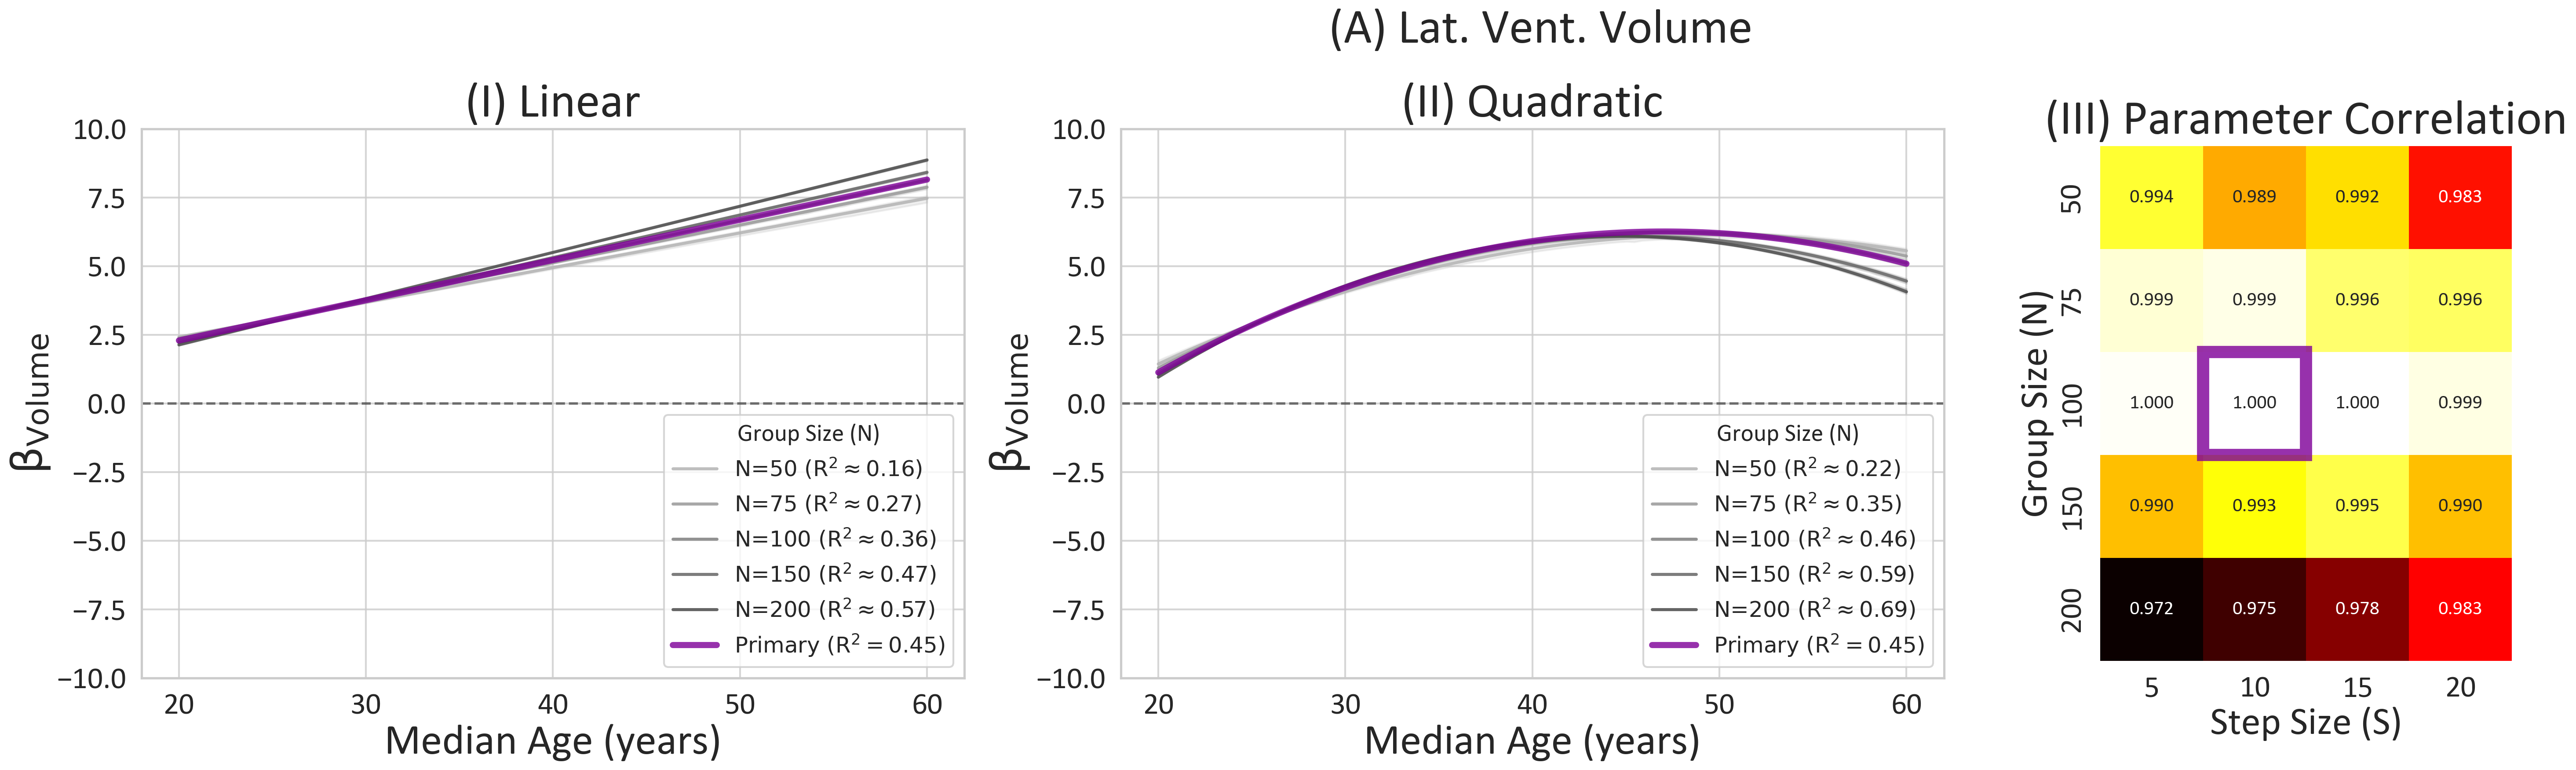

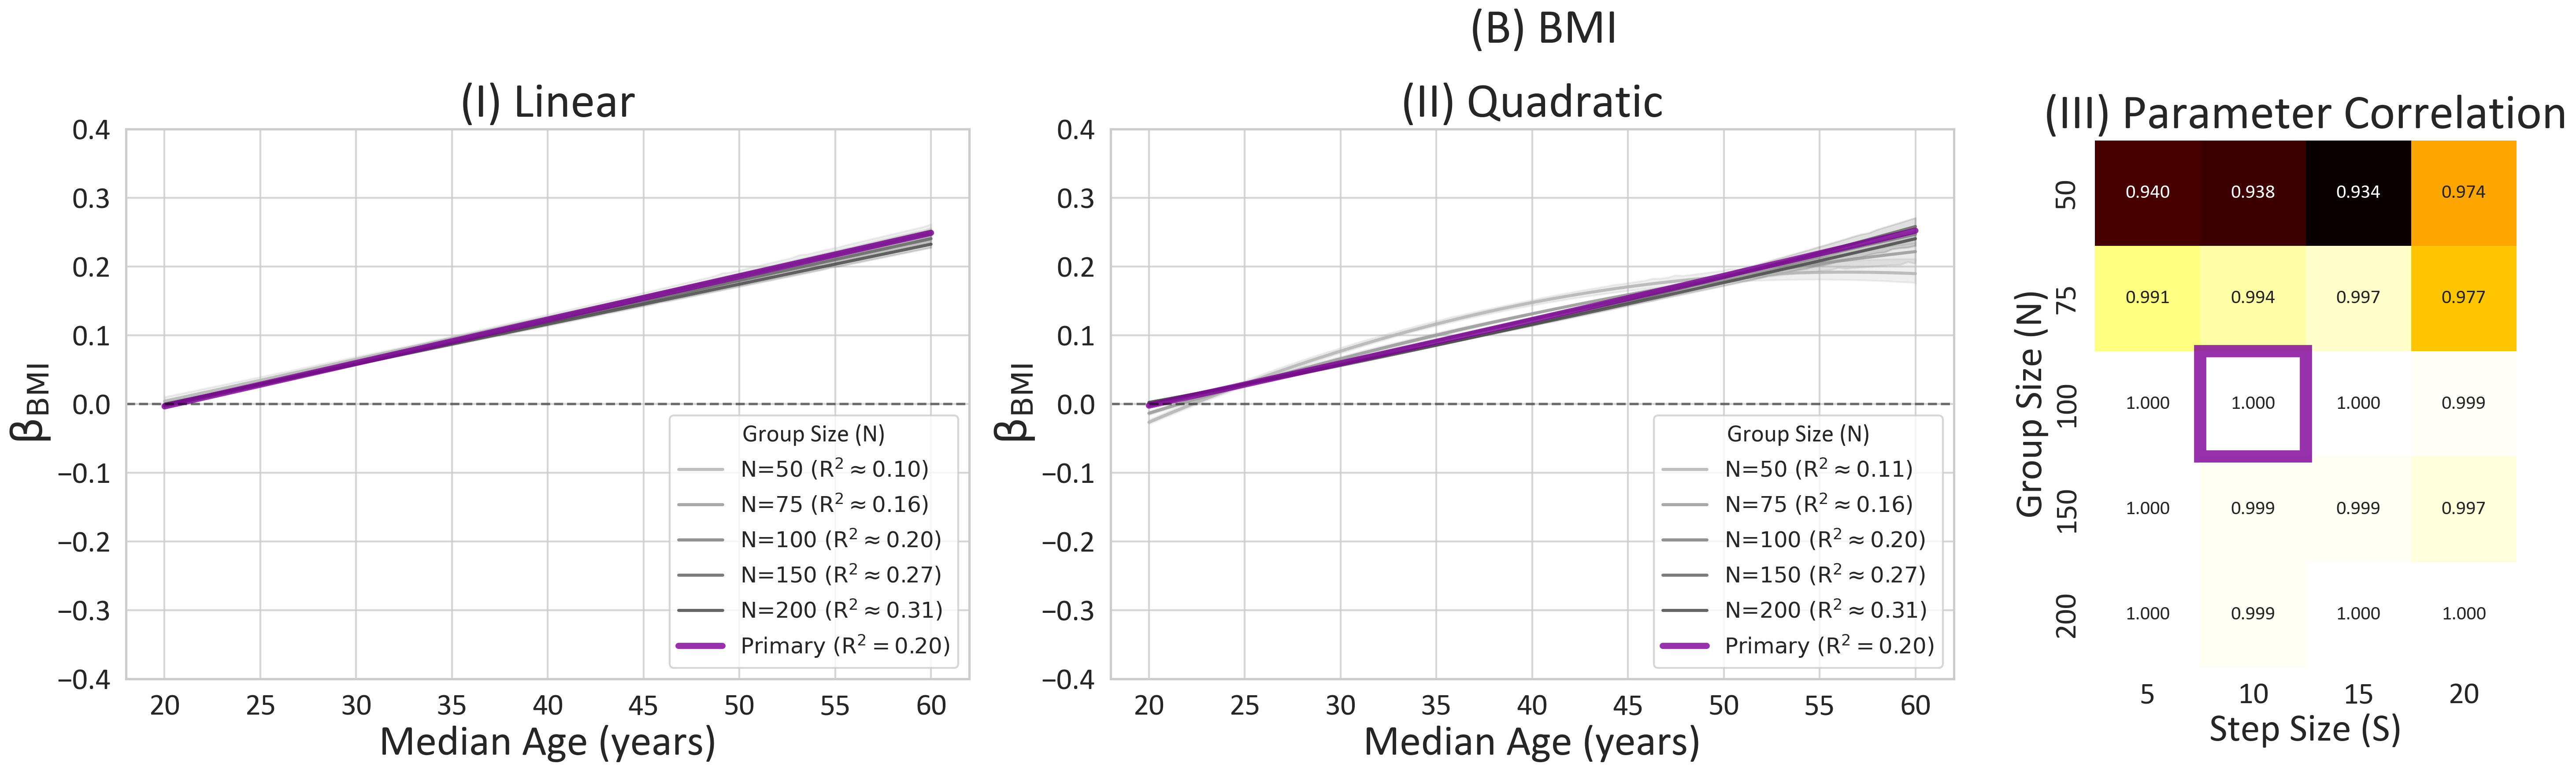

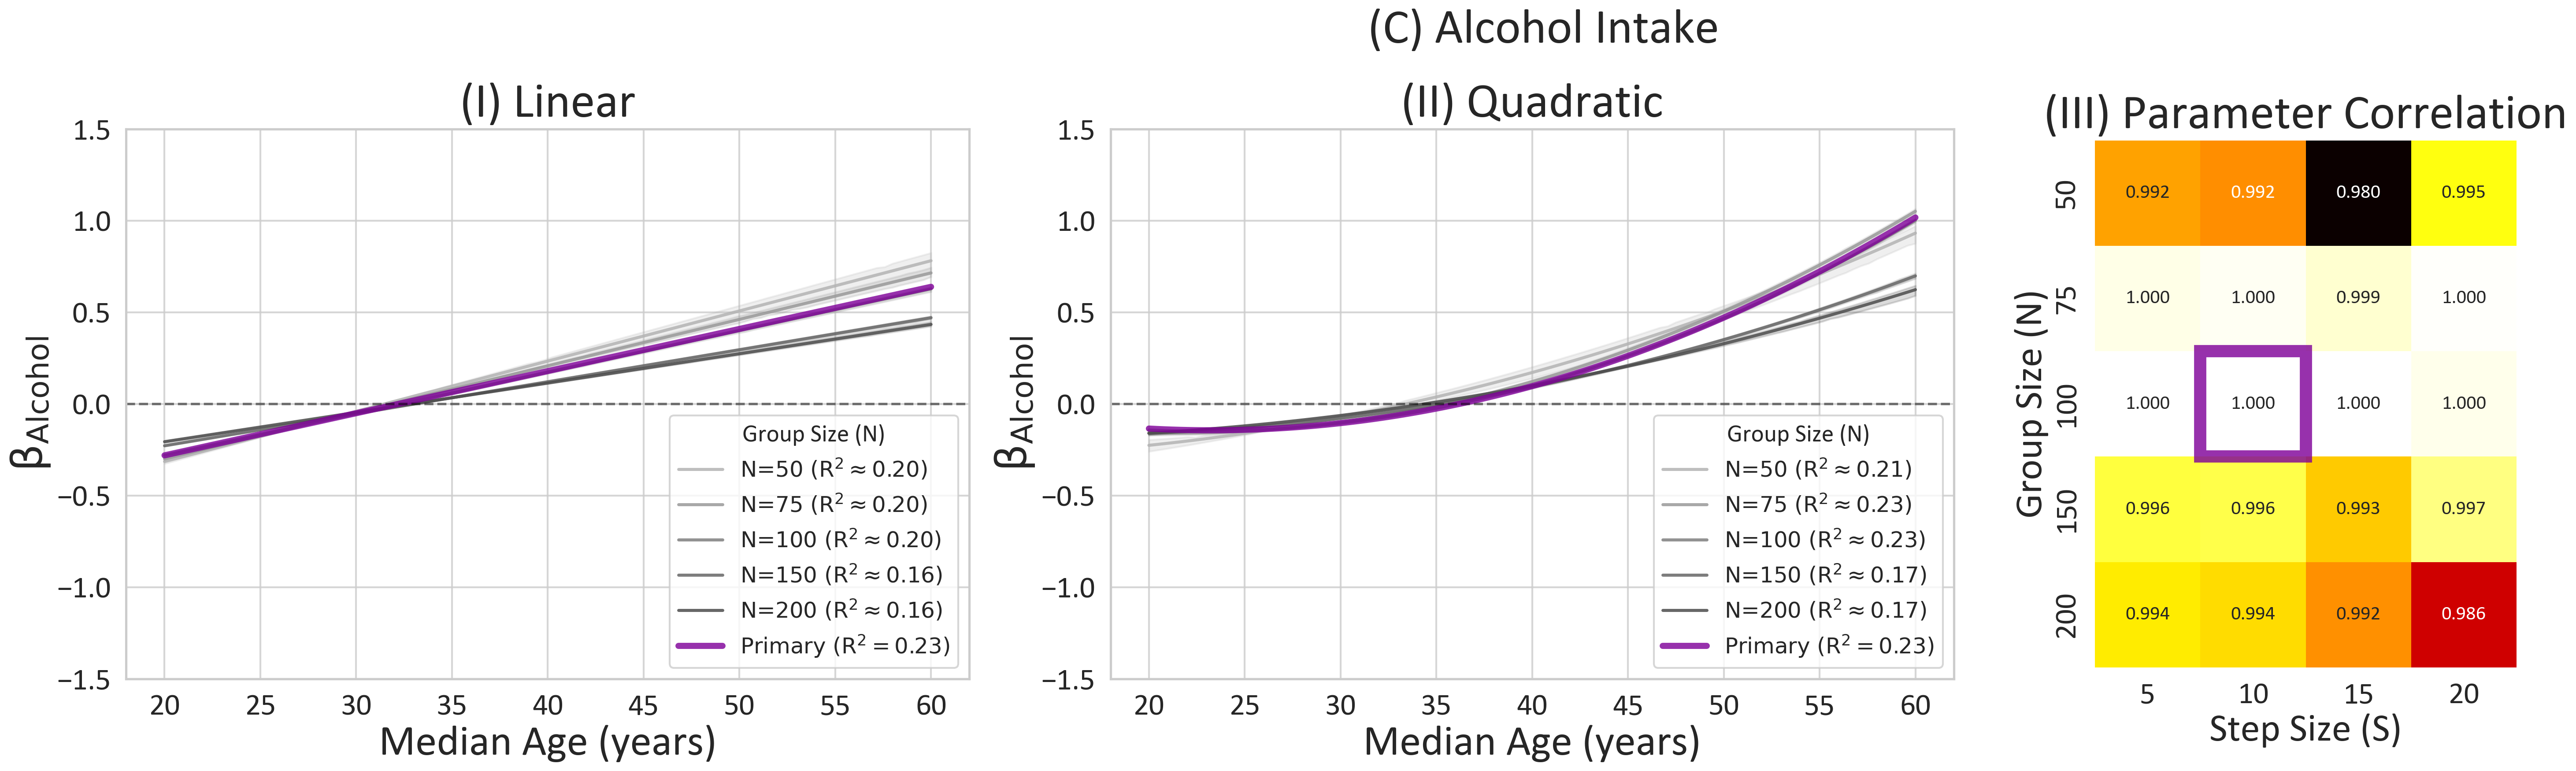

In [47]:
chosen_n = 100
chosen_s = 10

for feature in features_of_interest:
    feature_df = []
    lin_predictions_df = []
    quad_predictions_df = []
    for group_size, step in product(group_sizes, steps):

        feature_no_lead = features_vis.get(feature, feature)
        feature_no_lead = (
            " ".join(feature_no_lead.split(" ")[1:])
            if feature_no_lead.startswith("(")
            else feature_no_lead
        )


        out_dir = OUTPUT_DIR / f"N{group_size}_S{step}"
        out_dir.mkdir(parents=True, exist_ok=True)

        bins_df = pd.read_csv(out_dir / f"{feature}_windows.csv")
        bins_df["N"] = group_size
        bins_df["step"] = step
        bins_df["group"] = bins_df.index + 1
        feature_df.append(bins_df)
        for model, target_list in zip(
            ["Lin", "Quad"], [lin_predictions_df, quad_predictions_df]
        ):
            pred_df = pd.read_csv(out_dir / f"{feature}_trajectory_{model}.csv")
            pred_df["N"] = group_size
            pred_df["step"] = step
            pred_df["x"] = pred_age
            target_list.append(pred_df)
    feature_df = pd.concat(feature_df, axis=0)
    # feature_df.to_csv(OUTPUT_DIR / f"{feature}_all_windows.csv", index=False)
    lin_predictions_df = pd.concat(lin_predictions_df, axis=0)
    quad_predictions_df = pd.concat(quad_predictions_df, axis=0)
        # break
    fig = plot_sensitivity_trajectories(feature, feature_df, lin_predictions_df, quad_predictions_df, chosen_n, chosen_s)
    title = features_vis.get(feature, feature)
    fig.suptitle(title, fontsize=40, y=0.98, x=0.61)
    plt.tight_layout()
    out_file = OUTPUT_DIR / f"{feature}_sensitivity_trajectory.png"
    savefig_nice(fig, out_file, dpi=400, tight=False, transparent=True)
    # break

In [25]:
from statsmodels.formula.api import ols

show_f = False

group_size = 100
step = 10

# plot (x axis is feature, y axis is target, size is age, color is sex)

features_of_interest = ["lateral_ventricles_mean", "BMI", "alcohol"]
for feature in features_of_interest:

    mpl.rcParams.update(
        {
            "axes.labelsize": 35,
            "ytick.labelsize": 25,
            "xtick.labelsize": 25,
            "font.family": "Calibri",
        }
    )

    feature_no_lead = features_vis.get(feature, feature)
    feature_no_lead = (
        " ".join(feature_no_lead.split(" ")[1:])
        if feature_no_lead.startswith("(")
        else feature_no_lead
    )

    # Fit a linear model with OLS (include interactions)
    # for feature in features_of_interest:
    formula_int = f"{target} ~ {feature} * age_at_scan"
    formula_raw = f"{target} ~ {feature} + age_at_scan"
    model_int = wls(formula_int, data=df, weights=df["postrat_weight"])
    model_raw = wls(formula_raw, data=df, weights=df["postrat_weight"])
    results_int = model_int.fit()
    results_raw = model_raw.fit()

    f, p, df_diff = results_int.compare_f_test(results_raw)

    # get the power of p
    p_exponent = np.ceil(np.log10(p))
    # p_smaller_than = f"p < $1e^$"

    title = features_vis.get(feature, feature)
    if p < 1e-3:
        subtitle = f"(I)\n$F_{{({int(df_diff)}, {int(results_int.df_resid)})}}= {f:.2f}, p < 1e^{{{int(p_exponent)}}}$"
    elif p < 0.05:
        subtitle = f"(I)\n$F_{{({int(df_diff)}, {int(results_int.df_resid)})}}= {f:.2f}, p < 0.05$"
    else:
        subtitle = f"(I)\n$F_{{({int(df_diff)}, {int(results_int.df_resid)})}}= {f:.2f},$ n.s."
    if not show_f:
        subtitle = subtitle.split("\n")[0]  # remove the second line

    # print(results.summary())
    # break
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    ax = axes[0]
    sns.scatterplot(
        data=df,
        # x="age_at_scan",
        y=target,
        x=feature,
        # hue="sex",
        ax=ax,
        # palette={"M": COL_WEIGHTED, "F": COL_RAW},
        color=COL_REF,
        alpha=0.7,
        edgecolor="none",
        legend=False,
    )
    # add regression line
    # simulate data for predictions
    lines = []
    labels = []
    for lab, results in zip(
        [
            "No Int.",
            "Int.",
        ],
        [results_raw, results_int],
    ):
        pred_df = pd.DataFrame(
            {
                "age_at_scan": np.linspace(df["age_at_scan"].min(), df["age_at_scan"].max(), 100),
                feature: np.linspace(df[feature].min(), df[feature].max(), 100),
            }
        )
        predictions = results.get_prediction(pred_df)
        predictions = predictions.summary_frame(alpha=0.05)
        # plot the regression line
        lines += ax.plot(
            pred_df[feature],
            predictions["mean"],
            color=COL_WEIGHTED if lab == "Int." else COL_RAW,
            linewidth=6,
        )
        # labels.append(s)
        # label = f"$R^2$ = {results.rsquared:.2f}"
        label = ""
        for feat in results.params.index:
            if feat in ["Intercept", "age_at_scan"]:
                continue
            if feature in feat:
                feat_vis = (
                    feat.replace(feature, feature_no_lead)
                    .replace("Lat. Vent. ", "")
                    .replace("Score", "")
                    .replace(" Intake", "")
                )
            feat_vis = feat_vis.replace("age_at_scan", "Age")
            if "Age" in feat_vis:
                label += "\n"
            label += f"$\\beta_{{{feat_vis}}}$ = {results.params[feat]:.2f}"
            pval = results.pvalues[feat]
            p_exponent = np.ceil(np.log10(pval))
            if pval < 1e-3:
                label += f", p < $1e^{{{int(p_exponent)}}}$"
            elif pval < 0.05:
                label += f", p < 0.05"
            else:
                label += f", n.s."
        labels.append(f"{lab} - {label}")
        ax.fill_between(
            pred_df[feature],
            predictions["mean_ci_lower"],
            predictions["mean_ci_upper"],
            color=COL_WEIGHTED if lab == "Int." else COL_RAW,
            alpha=0.3,
            # label=f"{lab} 95% CI",
        )

    # ax.set_title(title, fontsize=40,pad=20)
    fig.suptitle(title, fontsize=40, y=0.95)
    if subtitle:
        ax.set_title(subtitle, fontsize=40, pad=10)
    ax.set_xlabel(
        feature_no_lead + f" ({units.get(feature, '')})" if feature in units else feature_no_lead
    )
    ax.set_ylabel("BAG")
    ax.legend(lines, labels, fontsize=25, loc="lower right")
    ax.set_ylim(-30, 30)
    ax.axhline(0, color="black", linestyle="--", linewidth=3, alpha=0.5)
    # # ax.legend(lines, ["Effect Size"])
    # plt.tight_layout()

    ################################################ Rolling window analysis plot#######################################
    bins_df, mod_lin, mod_quad = rolling_window_analysis(
        df, x_col=feature, target=target, group_size=group_size, step=step
    )
    # _, mod_quad = rolling_window_analysis(
    #     df, x_col=feature, target=target, fit_quadratic=True, group_size=100
    # )
    bins_df["p < 0.05"] = bins_df["p"] < 0.05
    bins_df["size"] = bins_df["p < 0.05"].map({True: 100, False: 50}).astype(float)
    f, p, df_diff = mod_quad.compare_f_test(mod_lin)

    if p < 1e-3:
        subtitle = f"(II)\n$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f}, p < 1e^{{{int(np.ceil(np.log10(p)))}}}$"
    elif p < 0.05:
        subtitle = f"(II)\n$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f}, p < 0.05$"
    else:
        subtitle = f"(II)\n$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f},$ n.s."

    if not show_f:
        subtitle = subtitle.split("\n")[0]

    ax = axes[1]

    sns.scatterplot(
        data=bins_df,
        x="median_age",
        y=f"{feature}_beta",
        # make p<0.05 star markers
        style="p < 0.05",
        markers={True: "*", False: "o"},
        # make p<0.05 larger
        size="size",
        sizes=(100, 200),
        # make start markers red and o markers blue
        hue="p < 0.05",
        palette={True: "red", False: COL_REF},
        ax=ax,
        legend=False,
        alpha=0.7,
        edgecolor="none",
    )
    # add regression lines
    pred_df = pd.DataFrame(
        {"median_age": np.linspace(bins_df["median_age"].min(), bins_df["median_age"].max(), 100)}
    )
    lines = []
    labels = []
    for model, col, is_quadratic in zip(
        [mod_lin, mod_quad], [COL_RAW, COL_WEIGHTED], [False, True]
    ):
        # simulate data for predictions
        predictions = model.get_prediction(pred_df)
        predictions = predictions.summary_frame(alpha=0.05)
        # plot the regression line
        lines += ax.plot(
            pred_df["median_age"],
            predictions["mean"],
            color=col,
            linewidth=6,
        )
        ax.fill_between(
            pred_df["median_age"],
            predictions["mean_ci_lower"],
            predictions["mean_ci_upper"],
            color=col,
            alpha=0.3,
            # label="95% CI",
        )
        feat = (
            feature_no_lead.replace("Lat. Vent. ", "").replace("Score", "").replace(" Intake", "")
        )
        # label = f"$\\beta_{{{feat}}}$ ~ $Age"
        # if is_quadratic:
        #     label += f" + Age^2$"
        # else:
        #     label += "$"
        label = "Quadratic - " if is_quadratic else "Linear - "

        p_exponent = np.ceil(np.log10(model.f_pvalue))
        if model.f_pvalue < 1e-3:
            p_addition = f"p < $1e^{{{int(p_exponent)}}}$"
        elif model.f_pvalue < 0.05:
            p_addition = f"p < 0.05"
        else:
            p_addition = f"n.s."

        label += f"$R^2$ = {model.rsquared:.2f}, {p_addition}"
        labels += [label]

    ax.axhline(0, color="black", linestyle="--", linewidth=2)
    ax.legend(lines, labels, fontsize=25, loc="lower right")
    ax.set_ylim(ylims.get(feature))
    ax.set_title(subtitle, fontsize=40, pad=10)
    ax.set_xlabel("Median Age (years)")
    ax.set_ylabel(f"$\\beta_{{{feat}}}$")

    savefig_nice(fig, OUTPUT_DIR / f"example1_{feature}.png", dpi=400, tight=True)
    # break

KeyError: 'postrat_weight'

In [ ]:
features_of_interest = [
    "lateral_ventricles_mean",
    "BMI",
    "caffeine",
    "alcohol",
    "psqi",
    # "relationship_duration",
    # "water",
    "smoking",
    # "screen_time"
]

df_of_interest = df[features_of_interest + [target, "postrat_weight", "age_at_scan"]]
df_of_interest["smoking"] = df_of_interest["smoking"].fillna(df_of_interest["smoking"].mode()[0])
df_of_interest = df_of_interest.fillna(df_of_interest.mean())

/tmp/ipykernel_526625/494265933.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_of_interest["smoking"] = df_of_interest["smoking"].fillna(df_of_interest["smoking"].mode()[0])


In [ ]:
from sklearn.calibration import cross_val_predict
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from itertools import combinations
from tqdm import tqdm


# ranging from 1 to n(features)
n_features = len(features_of_interest)
results = pd.DataFrame(
    columns=["n_features", "feature_combination", "mse", "r2", "mae", "adj_r2", "aic"]
)

age_regressor = wls(
    "stacked_BAG ~ age_at_scan", data=df_of_interest, weights=df_of_interest["postrat_weight"]
).fit()
df_of_interest["stacked_BAG_no_age"] = age_regressor.resid

for n in tqdm(range(1, n_features + 1), desc="Feature Combinations"):
    # create all combinations of n features
    feature_combinations = combinations(features_of_interest, n)
    for combo in feature_combinations:
        # print(f"Testing combination: {combo}")
        X = df_of_interest[list(combo) + ["age_at_scan"]]
        y = df_of_interest[target]

        # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        X_const = add_constant(X)
        model = sm.WLS(y, X_const, weights=df_of_interest["postrat_weight"]).fit()
        adj_r2 = model.rsquared_adj
        aic = model.aic

        # cross - val prediction
        model = LinearRegression()
        y_pred = cross_val_predict(model, X, y, cv=10)
        mse = mean_squared_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        results.loc[len(results)] = [
            n,
            str(combo),
            mse,
            r2,
            mae,
            adj_r2,
            aic,
        ]
        # break
    # break

Feature Combinations: 100%|██████████| 6/6 [00:01<00:00,  5.04it/s]


In [ ]:
from sklearn.inspection import permutation_importance


permutation_importance_df = pd.DataFrame(columns=["feature", "importance", "std", "p_value"])
model.fit(X, y, sample_weight=df_of_interest["postrat_weight"])
res = permutation_importance(
    model,
    X,
    y,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

In [ ]:
permutation_importance_df["feature"] = X.columns
permutation_importance_df["importance"] = res.importances_mean
permutation_importance_df["std"] = res.importances_std
permutation_importance_df.sort_values(by="importance", ascending=False)

,feature,importance,std,p_value
0,lateral_ventricles_mean,4.345281,0.328024,NaN
6,age_at_scan,2.085402,0.160601,NaN
1,BMI,0.209469,0.044107,NaN
2,caffeine,0.010023,0.003488,NaN
5,smoking,0.002030,0.008762,NaN
4,psqi,-0.017737,0.020976,NaN
3,alcohol,-0.073545,0.109767,NaN


In [ ]:
results.sort_values(by="adj_r2", ascending=False)

,n_features,feature_combination,mse,r2,mae,adj_r2,aic
44,4,"('lateral_ventricles_mean', 'BMI', 'alcohol', ...",18.218495,0.068899,3.339502,0.137558,17058.552945
59,5,"('lateral_ventricles_mean', 'BMI', 'alcohol', ...",18.229113,0.068357,3.338080,0.137314,17060.278938
56,5,"('lateral_ventricles_mean', 'BMI', 'caffeine',...",18.131198,0.073361,3.325407,0.137255,17060.455728
62,6,"('lateral_ventricles_mean', 'BMI', 'caffeine',...",18.156831,0.072051,3.327000,0.136995,17062.231211
22,3,"('lateral_ventricles_mean', 'BMI', 'alcohol')",18.202003,0.069742,3.336963,0.136957,17059.352177
...,...,...,...,...,...,...,...
17,2,"('caffeine', 'smoking')",19.504600,0.003170,3.413856,-0.000102,17438.924329
4,1,"('psqi',)",19.624507,-0.002958,3.436003,-0.000269,17438.356428
39,3,"('caffeine', 'psqi', 'smoking')",19.528108,0.001968,3.415946,-0.000287,17440.399653
5,1,"('smoking',)",19.599906,-0.001701,3.429446,-0.000556,17439.097420


<Axes: xlabel='n_features', ylabel='adj_r2'>

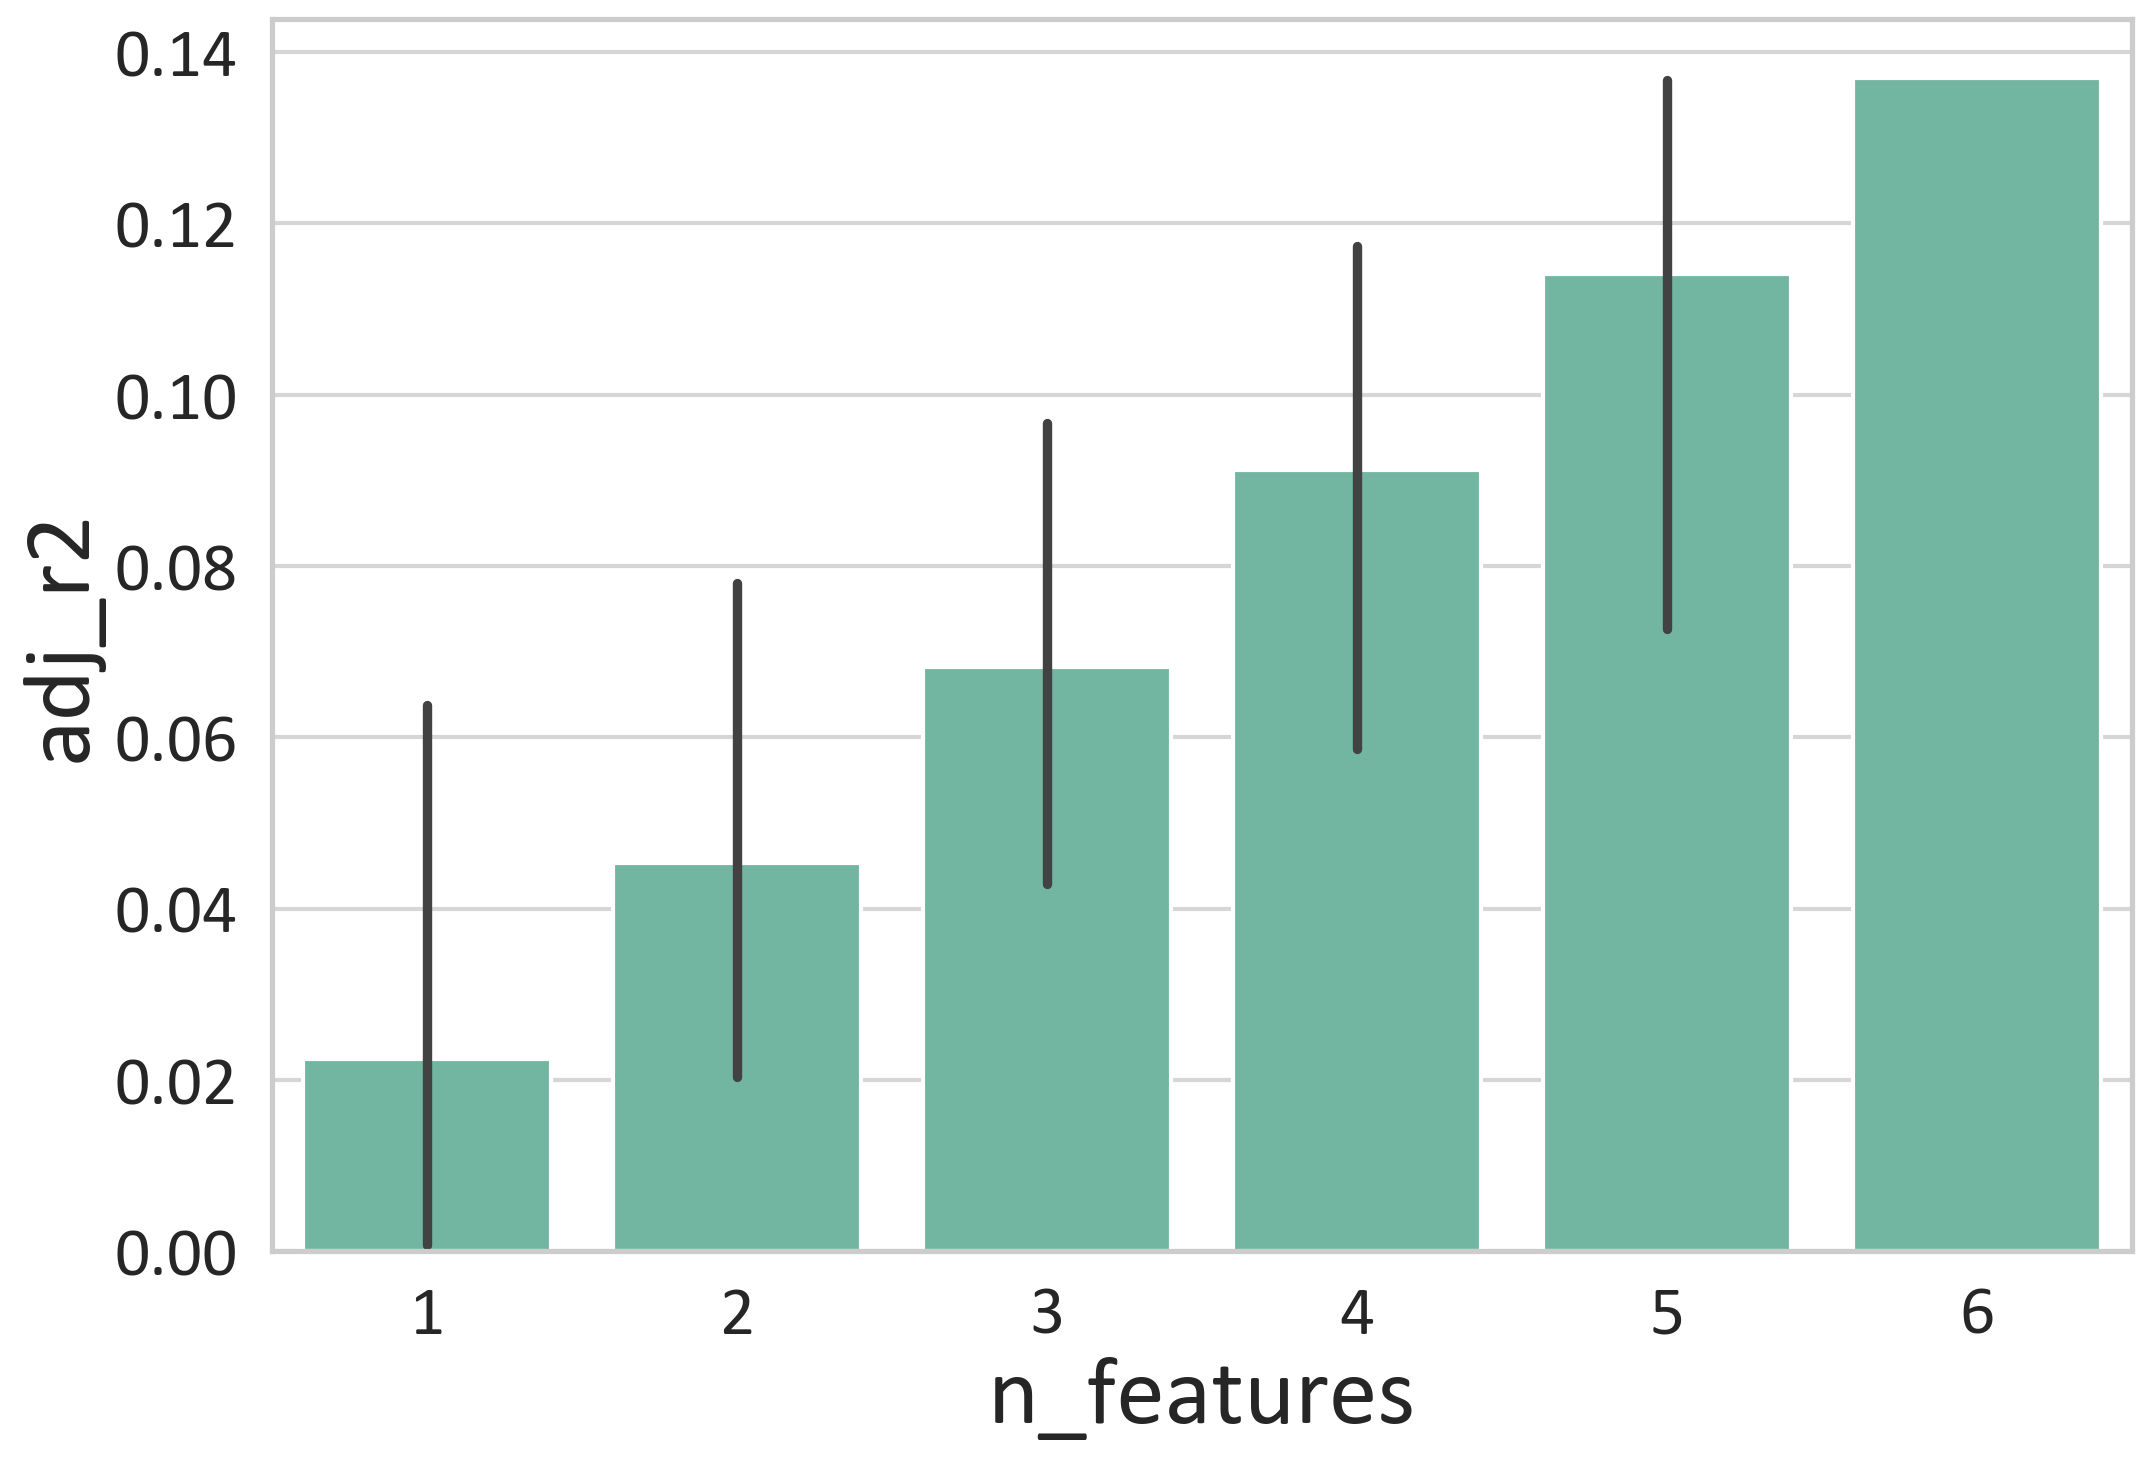

In [ ]:
sns.barplot(
    data=results,
    x="n_features",
    y="adj_r2",
    # hue="feature_combination",
    # palette="Set2",
    # ci=None,
)